(4080, 2296, 3)


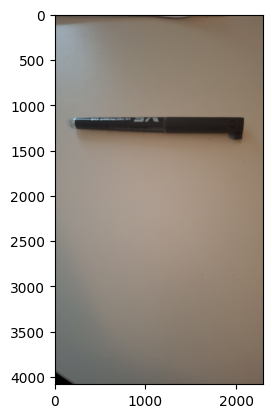

In [1]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import cv2

# Step 1: Load the image
image_path = '20250327_171942.jpg'  # Replace with the path to your image
image = cv2.imread(image_path)

# Convert from BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image_rgb.shape)
plt.imshow(image_rgb)
plt.show()
plt.close()

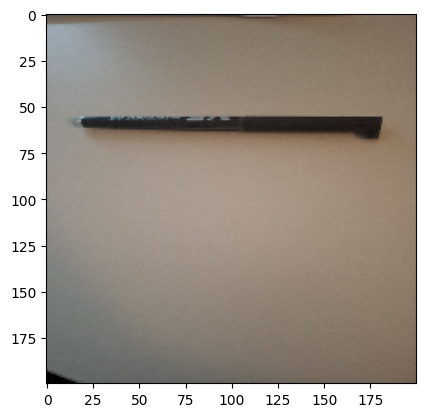

In [2]:
image_resized=cv2.resize(image_rgb,(200,200
                                    )) #resize image for faster processing
plt.imshow(image_resized)
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

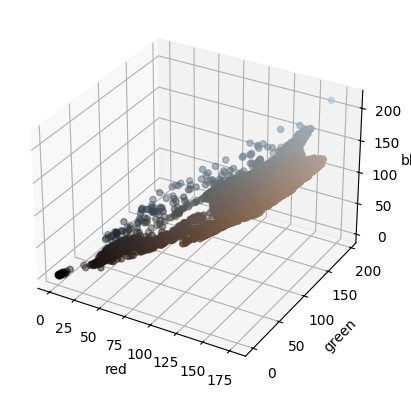

In [3]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()
reshaped_image=image_resized.reshape(-1,3) #we reshape xy pixels of the image into 1D vector of length nx * ny for point classification
# creating 3d plot using matplotlib
# in python
plt.clf()
# for creating a responsive plot

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
reshaped_image.shape


# For each set of style and range settings, plot n random points in the box
# defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
red=[]
green=[]
blue=[]
for index,element in enumerate(reshaped_image) :
    red.append(reshaped_image[index][0])
    green.append(reshaped_image[index][1])
    blue.append(reshaped_image[index][2])

red=np.array(red)
green=np.array(green)
blue=np.array(blue)


fig1 = plt.figure()
ax = fig1.add_subplot(111, projection='3d')

ax.scatter(red, green, blue,c=np.stack((red/255, green/255, blue/255), axis=-1), marker='o')
ax.set_xlabel('red')
ax.set_ylabel('green')
ax.set_zlabel('blue')
plt.show()
plt.close()

##PREPROCESSING FOR MODELLING

<Figure size 640x480 with 0 Axes>

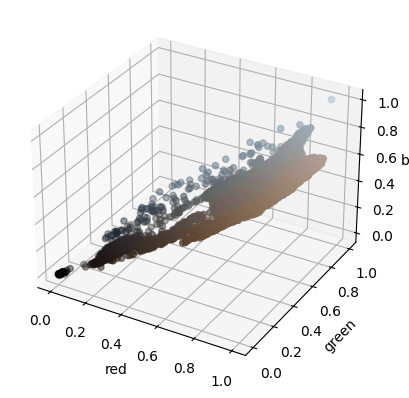

In [4]:
from sklearn.preprocessing import MinMaxScaler
plt.clf()
scaler=MinMaxScaler()

red_transf = MinMaxScaler().fit_transform(red.reshape(-1,1))

green_transf =MinMaxScaler().fit_transform(green.reshape(-1,1))

blue_transf= MinMaxScaler().fit_transform(blue.reshape(-1,1))


fig2 = plt.figure()
ax = fig2.add_subplot(111, projection='3d')

ax.scatter(red_transf, green_transf, blue_transf,c=np.stack((red/255, green/255, blue/255), axis=-1), marker='o')
ax.set_xlabel('red')
ax.set_ylabel('green')
ax.set_zlabel('blue')

plt.show()
plt.close()

In [5]:
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_validate
from sklearn.metrics import silhouette_score
X=scaler.fit_transform(reshaped_image)
k_range = range(2,10)
k_cycle=[]
k_index=[]
k_inertia=[]
silhouette=[]
centroids_k=[]
labels_k=[]
for k in k_range:
    print (f"cycle number is {k}")
    k_index.append(k)
    model = KMeans (n_clusters=k,random_state=42,init="random",max_iter=500)
    model.fit(X)
    centroids_k.append(model.cluster_centers_)  # Get cluster centers
    labels_k.append(model.labels_)  # Get labels for each point
    k_inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X, model.labels_, metric='euclidean'))
    # Apply the elbow method to find the optimal number of clusters.

#lookup https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html#sklearn.metrics.silhouette_score
#for automatic inflection point evaluation in elbow method

cycle number is 2


/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cycle number is 3


/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cycle number is 4


...

/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cycle number is 8


/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cycle number is 9


/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


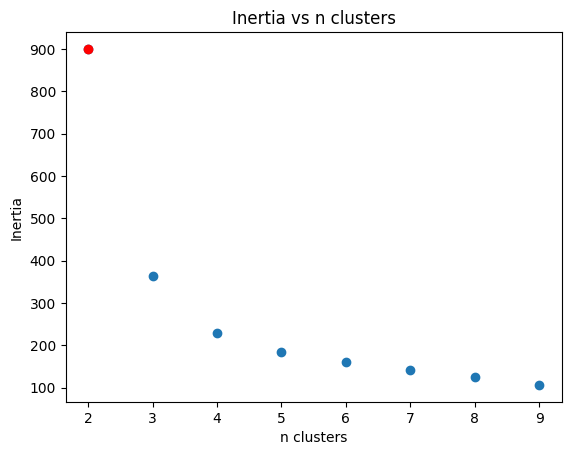

In [6]:
# YOUR CODE HERE
plt.clf()
maxsil=max(silhouette)
indexk=silhouette.index(maxsil)
plt.scatter(k_index,k_inertia)
plt.scatter(k_index[indexk],k_inertia[indexk],c="r")
plt.title("Inertia vs n clusters")
plt.xlabel("n clusters")
plt.ylabel("Inertia")
plt.show()
plt.close()

In [7]:
centroids_k[-1]

array([[0.94394387, 0.77328525, 0.65082854],
       [0.48404402, 0.37495047, 0.2960935 ],
       [0.86484037, 0.74146573, 0.64148562],
       [0.71143164, 0.55997287, 0.44008496],
       [0.21000166, 0.17007905, 0.14326315],
       [0.85310042, 0.68888786, 0.55788212],
       [0.85469371, 0.80486425, 0.75432652],
       [0.61853974, 0.56745232, 0.50551672],
       [0.77787631, 0.63612946, 0.5146216 ]])

[0 1 2 3 4 5 6 7 8] [81634 51917 70581 36835 14908 30662 15231  8805  9427]
0


<Figure size 640x480 with 0 Axes>

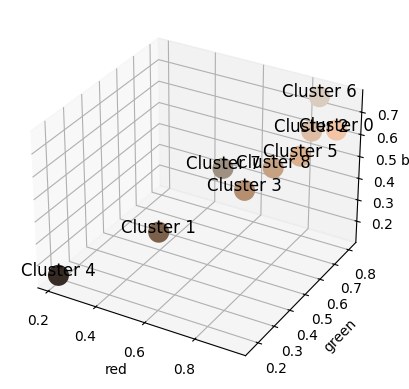

In [ ]:
plt.clf()

max_centroids = centroids_k[-1]
red_centroid=[]
green_centroid=[]
blue_centroid=[]
for k in range(len(max_centroids)):
    red_centroid.append(max_centroids[k][0])
    green_centroid.append(max_centroids[k][1])
    blue_centroid.append(max_centroids[k][2])

red2=np.array(red_centroid)
green2=np.array(green_centroid)
blue2=np.array(blue_centroid)


fig4 = plt.figure()
ax = fig4.add_subplot(111, projection='3d')

ax.scatter(red2, green2, blue2,c=np.stack((red2, green2, blue2), axis=-1),s=200, marker='o',alpha=1)

for i in range(len(red2)):
    ax.text(red2[i], green2[i], blue2[i], f'Cluster {i}', color='black', fontsize=12, ha='center')
    
ax.set_xlabel('red')
ax.set_ylabel('green')
ax.set_zlabel('blue')    


plt.show()
plt.close()

In [ ]:
# Step 5: Count the number of pixels in each cluster
unique, counts = np.unique(labels_k, return_counts=True)
print(unique,counts)
maxcounts=max(counts)
labelmax=counts.argmax()
print(labelmax)
total=counts.sum()
percentage_counts=counts/total

percentage_counts*100


[0 1 2 3 4 5 6 7 8] [81634 51917 70581 36835 14908 30662 15231  8805  9427]
0


array([25.510625 , 16.2240625, 22.0565625, 11.5109375,  4.65875  ,
        9.581875 ,  4.7596875,  2.7515625,  2.9459375])

In [95]:
rgb_centroids=(centroids_k[-1]*255).round()
rgb_centroids[0]


array([241., 197., 166.])

In [105]:
import pandas as pd

color_df = pd.read_csv("ral_classic.csv")
color_df.head(10)


,RAL,RGB,HEX,CMYK,LRV,English,German,French,Spanish,Italian,Dutch
0,RAL 1000,205-186-136,#CDBA88,0-9-34-20,51.79,Green beige,Grünbeige,Beige vert,Beige verdoso,Beige verdastro,Groenbeige
1,RAL 1001,208-176-132,#D0B084,0-15-37-18,48.09,Beige,Beige,Beige,Beige,Beige,Beige
2,RAL 1002,210-170-109,#D2AA6D,0-19-48-18,45.07,Sand yellow,Sandgelb,Jaune sable,Amarillo arena,Giallo sabbia,Zandgeel
3,RAL 1003,249-169-0,#F9A900,0-32-100-2,49.05,Signal yellow,Signalgelb,Jaune de sécurité,Amarillo señales,Giallo segnale,Signaalgeel
4,RAL 1004,228-158-0,#E49E00,0-31-100-11,42.13,Golden yellow,Goldgelb,Jaune or,Amarillo oro,Giallo oro,Goudgeel
5,RAL 1005,203-143-0,#CB8F00,0-30-100-20,34.15,Honey yellow,Honiggelb,Jaune miel,Amarillo miel,Giallo miele,Honinggeel
6,RAL 1006,225-144-0,#E19000,0-36-100-12,37.45,Maize yellow,Maisgelb,Jaune maïs,Amarillo maíz,Giallo polenta,Maisgeel
7,RAL 1007,232-140-0,#E88C00,0-40-100-9,37.63,Daffodil yellow,Narzissengelb,Jaune narcisse,Amarillo narciso,Giallo narciso,Narcissengeel
8,RAL 1011,175-128-80,#AF8050,0-27-54-31,27.65,Brown beige,Braunbeige,Beige brun,Beige pardo,Beige marrone,Bruinbeige
9,RAL 1012,221-175-40,#DDAF28,0-21-82-13,47.83,Lemon yellow,Zitronengelb,Jaune citron,Amarillo limón,Giallo limone,Citroengeel


In [108]:
def convert_to_list(color_string):
    return np.array(list(map(int, color_string.split('-'))))

# Apply the conversion to the column
color_df['RGB_converted'] = color_df['RGB'].apply(convert_to_list).copy()
rgb_array = np.array(color_df["RGB"]).copy()
color_df.head(10)


,RAL,RGB,HEX,CMYK,LRV,English,German,French,Spanish,Italian,Dutch,RGB_converted
0,RAL 1000,205-186-136,#CDBA88,0-9-34-20,51.79,Green beige,Grünbeige,Beige vert,Beige verdoso,Beige verdastro,Groenbeige,"[205, 186, 136]"
1,RAL 1001,208-176-132,#D0B084,0-15-37-18,48.09,Beige,Beige,Beige,Beige,Beige,Beige,"[208, 176, 132]"
2,RAL 1002,210-170-109,#D2AA6D,0-19-48-18,45.07,Sand yellow,Sandgelb,Jaune sable,Amarillo arena,Giallo sabbia,Zandgeel,"[210, 170, 109]"
3,RAL 1003,249-169-0,#F9A900,0-32-100-2,49.05,Signal yellow,Signalgelb,Jaune de sécurité,Amarillo señales,Giallo segnale,Signaalgeel,"[249, 169, 0]"
4,RAL 1004,228-158-0,#E49E00,0-31-100-11,42.13,Golden yellow,Goldgelb,Jaune or,Amarillo oro,Giallo oro,Goudgeel,"[228, 158, 0]"
5,RAL 1005,203-143-0,#CB8F00,0-30-100-20,34.15,Honey yellow,Honiggelb,Jaune miel,Amarillo miel,Giallo miele,Honinggeel,"[203, 143, 0]"
6,RAL 1006,225-144-0,#E19000,0-36-100-12,37.45,Maize yellow,Maisgelb,Jaune maïs,Amarillo maíz,Giallo polenta,Maisgeel,"[225, 144, 0]"
7,RAL 1007,232-140-0,#E88C00,0-40-100-9,37.63,Daffodil yellow,Narzissengelb,Jaune narcisse,Amarillo narciso,Giallo narciso,Narcissengeel,"[232, 140, 0]"
8,RAL 1011,175-128-80,#AF8050,0-27-54-31,27.65,Brown beige,Braunbeige,Beige brun,Beige pardo,Beige marrone,Bruinbeige,"[175, 128, 80]"
9,RAL 1012,221-175-40,#DDAF28,0-21-82-13,47.83,Lemon yellow,Zitronengelb,Jaune citron,Amarillo limón,Giallo limone,Citroengeel,"[221, 175, 40]"


In [ ]:
X.shape

(216, 1)

In [111]:
from sklearn.neighbors import KNeighborsClassifier
X=color_df[["RGB_converted"]].copy()
Y = color_df["RAL"].copy()
classifier = KNeighborsClassifier(n_neighbors=1)

classifier.fit(X=X,y=Y)


ValueError: setting an array element with a sequence.